# Football Transfer Fee Prediction Pipeline

This notebook implements a clean, production-oriented version of the transfer fee prediction model. It includes data extraction, sophisticated feature engineering (including FIFA ratings integration), and model evaluation using both Linear Regression and Random Forest Regressor.

## 1. Environment Setup and Data Loading

In [1]:
!pip install fuzzywuzzy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import os
import zipfile
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from fuzzywuzzy import process

# Constants
TRANSFERS_PATH = '../data/transfers.zip'
RATINGS_PATH = '../data/ratings.zip'

def normalize_text(s):
    if not isinstance(s, str): return s
    return unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('utf-8')

transfers = pd.read_csv(TRANSFERS_PATH, compression='zip')
transfers.head()

C:\Users\thoma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


## 2. Initial Data Cleaning

We clean the seasons, normalize positions, and remove inconsistent rows (e.g., Age 0).

In [3]:
transfers['Season_transferred']=transfers['Season'].str.split('-').str[0]
transfers = transfers.astype({'Season_transferred':'int64'})
transfers = transfers.drop(columns =['Season'])
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Market_value,Transfer_fee,Season_transferred
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,NaN,60000000,2000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,NaN,56810000,2000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,NaN,40000000,2000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,NaN,36150000,2000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,NaN,34500000,2000


In [4]:
print(transfers.Position.unique())
transfers.Position = transfers.Position.replace(to_replace=['Second Striker','Centre-Forward','Sweeper'],value = ['Forward','Forward','Defender'])
print(transfers.Position.unique())

<ArrowStringArray>
[      'Right Winger',     'Centre-Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',     'Second Striker',         'Goalkeeper',
         'Right-Back',      'Left Midfield',          'Left-Back',
     'Right Midfield',            'Forward',            'Sweeper',
           'Defender',         'Midfielder']
Length: 17, dtype: str
<ArrowStringArray>
[      'Right Winger',            'Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',         'Goalkeeper',         'Right-Back',
      'Left Midfield',          'Left-Back',     'Right Midfield',
           'Defender',         'Midfielder']
Length: 14, dtype: str


In [5]:
transfers.Age.unique()
transfers_weird = transfers.loc[transfers.Age == 0]
print(transfers_weird)

                  Name Position  Age Team_from    League_from  Team_to  \
236  Marzouq Al-Otaibi  Forward    0    Shabab   Saudi Arabia  Ittihad   

         League_to  Market_value  Transfer_fee  Season_transferred  
236   Saudi Arabia           NaN       2000000                2000  


In [6]:
transfers_midfield = transfers.loc[transfers.Position == 'Midfielder']
print(transfers_midfield.head(20))
transfers_defenders = transfers.loc[transfers.Position =='Defender']
print(transfers_defenders.head(20))

             Name    Position  Age Team_from     League_from Team_to  \
705  Tony Dinning  Midfielder   27    Wolves  First Division   Wigan   

                       League_to  Market_value  Transfer_fee  \
705  Second Division (bis 03/04)           NaN       1130000   

     Season_transferred  
705                2002  
                Name  Position  Age      Team_from     League_from  \
471    Thomas Hengen  Defender   26  VfL Wolfsburg    1.Bundesliga   
652  Sergio Hellings  Defender   17       Ajax U19  U19 Eredivisie   

            Team_to     League_to  Market_value  Transfer_fee  \
471  1.FC K'lautern  1.Bundesliga           NaN       2250000   
652  Anderlecht U19       Belgium           NaN       2000000   

     Season_transferred  
471                2001  
652                2002  


In [7]:
transfers_cleaned= transfers[~((transfers.Position=='Midfielder')|(transfers.Position=='Defender')|(transfers.Age ==0))]
transfers_cleaned['Transfer_fee_in_mln']=transfers_cleaned['Transfer_fee']/1000000
transfers_cleaned['Market_value_in_mln']=transfers_cleaned['Market_value']/1000000
transfers_cleaned = transfers_cleaned.drop(labels = ['Transfer_fee','Market_value'],axis = 1)
pd.to_datetime(transfers_cleaned['Season_transferred'],format ='%Y')
transfers_cleaned.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000,60.00,NaN
1,Hernán Crespo,Forward,25,Parma,Serie A,Lazio,Serie A,2000,56.81,NaN
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000,40.00,NaN
3,Gabriel Batistuta,Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000,36.15,NaN
4,Nicolas Anelka,Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000,34.50,NaN


In [8]:
season_fee_stats = (
    transfers_cleaned
    .groupby('Season_transferred')['Transfer_fee_in_mln']
    .agg(mean_transfer_fee='mean', median_transfer_fee='median')
    .reset_index()
) #saving aggregate stats if called back later

## 3. Feature Engineering: Basic Features

Extracting Lastnames and normalizing text for reliable merging.

In [9]:
transfers_2015_18 = transfers_cleaned[transfers_cleaned['Season_transferred'] > 2014].copy()
transfers_2015_18['Lastname'] = transfers_2015_18['Name'].apply(lambda x: x.split(' ')[-1])

for col in ['Lastname', 'Team_from', 'Team_to']:
    transfers_2015_18[col] = transfers_2015_18[col].apply(normalize_text)

transfers_2015_18.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,Lastname
3713,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,Bruyne
3714,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,Sterling
3715,Ángel Di María,Right Winger,27,Man Utd,Premier League,Paris SG,Ligue 1,2015,63.0,50.0,Maria
3716,Anthony Martial,Left Winger,19,Monaco,Ligue 1,Man Utd,Premier League,2015,60.0,8.0,Martial
3717,Alex Teixeira,Attacking Midfield,26,Shakhtar D.,Premier Liga,JS Suning,Super League,2015,50.0,30.0,Teixeira


In [10]:
import zipfile

ratings_zip_path = '../data/ratings.zip'
with zipfile.ZipFile(ratings_zip_path) as zf:
    fifa_full_15 = pd.read_csv(zf.open('players_15.csv'))
    fifa_full_16 = pd.read_csv(zf.open('players_16.csv'))
    fifa_full_17 = pd.read_csv(zf.open('players_17.csv'))
    fifa_full_18 = pd.read_csv(zf.open('players_18.csv'))

fifa_full_15['Season'] = 2015
fifa_full_16['Season'] = 2016
fifa_full_17['Season'] = 2017
fifa_full_18['Season'] = 2018

# Quick schema inspection
print("Shapes:")
print("2015:", fifa_full_15.shape, "2016:", fifa_full_16.shape, "2017:", fifa_full_17.shape, "2018:", fifa_full_18.shape)

print("\nColumn count by year:")
print(len(fifa_full_15.columns), len(fifa_full_16.columns), len(fifa_full_17.columns), len(fifa_full_18.columns))

print("\nDo all years have identical columns?",
      set(fifa_full_15.columns) == set(fifa_full_16.columns) == set(fifa_full_17.columns) == set(fifa_full_18.columns))

# Merge full datasets for broader inspection
fifas_full_merged = pd.concat([fifa_full_15, fifa_full_16, fifa_full_17, fifa_full_18], ignore_index=True, sort=False)

print("\nMerged full dataset shape:", fifas_full_merged.shape)
print("\nFirst 50 columns:")
print(fifas_full_merged.columns[:50].tolist())

fifas_full_merged.head()
fifas_full_merged.sample(5, random_state=42)

Shapes:
2015: (15465, 105) 2016: (14881, 105) 2017: (17009, 105) 2018: (17592, 105)

Column count by year:
105 105 105 105

Do all years have identical columns? True

Merged full dataset shape: (64947, 105)

First 50 columns:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribb

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,Season
52569,192890,https://sofifa.com/player/192890/erbin-trejo/1...,E. Trejo,Erbín Trejo,27,1990-06-03,171,69,Mexico,Querétaro,...,66+1,66+1,66+1,67+1,66+1,62+1,62+1,62+1,66+1,2018
35671,194730,https://sofifa.com/player/194730/juan-carlos-m...,Juan Carlos,Juan Carlos Martín Corral,28,1988-01-20,187,82,Spain,Elche CF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
273,152554,https://sofifa.com/player/152554/gael-clichy/1...,G. Clichy,Gaël Clichy,28,1985-07-26,176,65,France,Manchester City,...,75+1,75+1,75+1,80+1,79+1,76+1,76+1,76+1,79+1,2015
16234,188942,https://sofifa.com/player/188942/victor-wanyam...,V. Wanyama,Victor Wanyama,24,1991-06-25,188,76,Kenya,Southampton,...,77+0,77+0,77+0,75+0,75+0,80+0,80+0,80+0,75+0,2016
20660,206018,https://sofifa.com/player/206018/igor-vetokele...,I. Vetokele,Igor Vetokele,23,1992-03-23,173,74,Angola,Charlton Athletic,...,45+0,45+0,45+0,50+0,47+0,42+0,42+0,42+0,47+0,2016


## 4. Advanced Feature Engineering: FIFA Ratings Integration

We load FIFA player ratings (Overall/Potential) and use multiple fallback strategies to recover missing metadata like Nationality.

In [11]:
nat_frames = []
with zipfile.ZipFile(RATINGS_PATH) as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr-2000}.csv'))
        nat_col = 'nationality_name' if 'nationality_name' in f.columns else ('nationality' if 'nationality' in f.columns else None)
        if nat_col is None: continue

        mini = f[['short_name', 'club', nat_col, 'overall', 'potential']].copy()
        mini['Lastname'] = mini['short_name'].str.split(' ').str[-1].apply(normalize_text)
        mini['club'] = mini['club'].apply(normalize_text)
        mini['Season_transferred'] = yr
        mini = mini.rename(columns={nat_col: 'Nationality'})
        nat_frames.append(mini)

fifa_nat = pd.concat(nat_frames, ignore_index=True)
fifa_nat['Nationality'] = fifa_nat['Nationality'].apply(normalize_text)

fifa_nat_best_club = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'club', 'Season_transferred'])
fifa_nat_best_name_season = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'Season_transferred'])

print(f'FIFA lookup rows (club-level): {len(fifa_nat_best_club)}')
print(f'FIFA lookup rows (lastname-season): {len(fifa_nat_best_name_season)}')

FIFA lookup rows (club-level): 63797
FIFA lookup rows (lastname-season): 46302


## 5. Dataset Merging and Fallback Recovery

We attempt to match transfers to FIFA data using Team_from, then Team_to, and finally a broader Lastname+Season search.

In [12]:
# Merge on Team_from
transfers_fe = transfers_2015_18.merge(
    fifa_nat_best_club.rename(columns={'club': 'Team_from', 'overall': 'overall_from', 'potential': 'potential_from'}),
    on=['Lastname', 'Team_from', 'Season_transferred'], how='left'
)

# Fallback on Team_to for nulls
null_mask = transfers_fe['overall_from'].isna()
to_lookup = fifa_nat_best_club.rename(columns={'club': 'Team_to', 'overall': 'overall_to', 'potential': 'potential_to', 'Nationality': 'Nat_to'})
transfers_fe = transfers_fe.merge(to_lookup, on=['Lastname', 'Team_to', 'Season_transferred'], how='left')

# Final broader fallback
transfers_fe['overall'] = transfers_fe['overall_from'].combine_first(transfers_fe['overall_to'])
transfers_fe['potential'] = transfers_fe['potential_from'].combine_first(transfers_fe['potential_to'])

final_df = transfers_fe.dropna(subset=['overall']).copy()
print(f"Nationality nulls after fallback: {final_df['Nationality'].isna().sum()} / {len(final_df)}")

Nationality nulls after fallback: 40 / 382


## 6. Engineered Indicators for Bias and Performance

Creating buckets for Age and Position, and purchasing power indicators for leagues and clubs.

In [13]:
#Purchasing power proxy
league_median = final_df.groupby('League_to')['Transfer_fee_in_mln'].median()
final_df['league_median_fee_to'] = final_df['League_to'].map(league_median)

# Age buckets
final_df['age_bucket'] = pd.cut(final_df['Age'], bins=[14, 20, 24, 27, 30, 50], labels=['<20', '20-23', '24-26', '27-29', '30+'])

# Position buckets
pos_map = {
    'Centre-Back': 'Defender', 'Right-Back': 'Defender', 'Left-Back': 'Defender',
    'Central Midfield': 'Midfielder', 'Attacking Midfield': 'Midfielder', 'Defensive Midfield': 'Midfielder',
    'Right Winger': 'Winger', 'Left Winger': 'Winger', 'Forward': 'Forward', 'Goalkeeper': 'Goalkeeper'
}
final_df['pos_group'] = final_df['Position'].map(pos_map).fillna('Other')

final_df.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,...,potential_from,short_name_y,Nat_to,overall_to,potential_to,overall,potential,league_median_fee_to,age_bucket,pos_group
0,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,...,86.0,NaN,NaN,NaN,NaN,81.0,86.0,14.55,20-23,Midfielder
1,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,...,86.0,NaN,NaN,NaN,NaN,80.0,86.0,14.55,<20,Winger
5,Christian Benteke,Forward,24,Aston Villa,Premier League,Liverpool,Premier League,2015,46.5,20.0,...,85.0,NaN,NaN,NaN,NaN,80.0,85.0,14.55,20-23,Forward
6,Nicolás Otamendi,Centre-Back,27,Valencia CF,LaLiga,Man City,Premier League,2015,44.6,25.0,...,84.0,NaN,NaN,NaN,NaN,80.0,84.0,14.55,24-26,Defender
7,Julian Draxler,Central Midfield,21,FC Schalke 04,1.Bundesliga,VfL Wolfsburg,1.Bundesliga,2015,43.0,22.0,...,85.0,NaN,NaN,NaN,NaN,80.0,85.0,10.25,20-23,Midfielder


# Fairness Framework

In [14]:
# Fairness framework for model evaluation
FAIRNESS_FRAMEWORK = {
    'objective': 'Check whether prediction quality and direction of error differ across groups.',
    'target': 'Transfer_fee_in_mln',
    'model_under_evaluation': 'Baseline Random Forest (no engineered FIFA features)',
    'sensitive_or_context_groups': ['League_from', 'Nationality', 'Region'],
    'minimum_group_size': 20,
    'metrics': [
        'Signed residual (mean/median): detect over- vs underprediction by group',
        'MAE and RMSE: compare error magnitude by group',
        'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values',
    ],
    'interpretation_notes': [
        'Negative residual means underprediction (actual fee > predicted fee).',
        'Positive residual means overprediction (actual fee < predicted fee).',
        'Group-level results should be interpreted with sample-size caution.',
    ],
}

for k, v in FAIRNESS_FRAMEWORK.items():
    print(f"{k}: {v}")

objective: Check whether prediction quality and direction of error differ across groups.
target: Transfer_fee_in_mln
model_under_evaluation: Baseline Random Forest (no engineered FIFA features)
sensitive_or_context_groups: ['League_from', 'Nationality', 'Region']
minimum_group_size: 20
metrics: ['Signed residual (mean/median): detect over- vs underprediction by group', 'MAE and RMSE: compare error magnitude by group', 'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values']
interpretation_notes: ['Negative residual means underprediction (actual fee > predicted fee).', 'Positive residual means overprediction (actual fee < predicted fee).', 'Group-level results should be interpreted with sample-size caution.']


Evaluation set size: 1409
Nationality coverage: 255 / 1409

=== Signed residual by League_from ===


,n,mean_residual,median_residual
League_from,,,
Liga NOS,50,-2.460,-0.138
Serie A,174,-1.941,-0.228
Premier Liga,53,-1.774,0.313
Premier League,194,-1.576,0.283
Ligue 1,129,-1.528,0.149
1.Bundesliga,62,-1.502,-0.266
Série A,70,-1.132,0.061
LaLiga,118,-0.976,0.632
First Division,20,-0.181,0.018



=== Signed residual by Nationality (n >= 20) ===


,n,mean_residual,median_residual
Nationality,,,
Brazil,28,-4.047,1.368
France,27,-1.131,2.574
Spain,20,1.207,2.449



=== Signed residual by Region ===


,n,mean_residual,median_residual
Region,,,
South America,59,-2.078,0.861
Other,1159,-0.877,0.277
W. Europe,130,-0.226,1.335
Africa,30,0.171,1.973
E. Europe,25,0.461,1.332


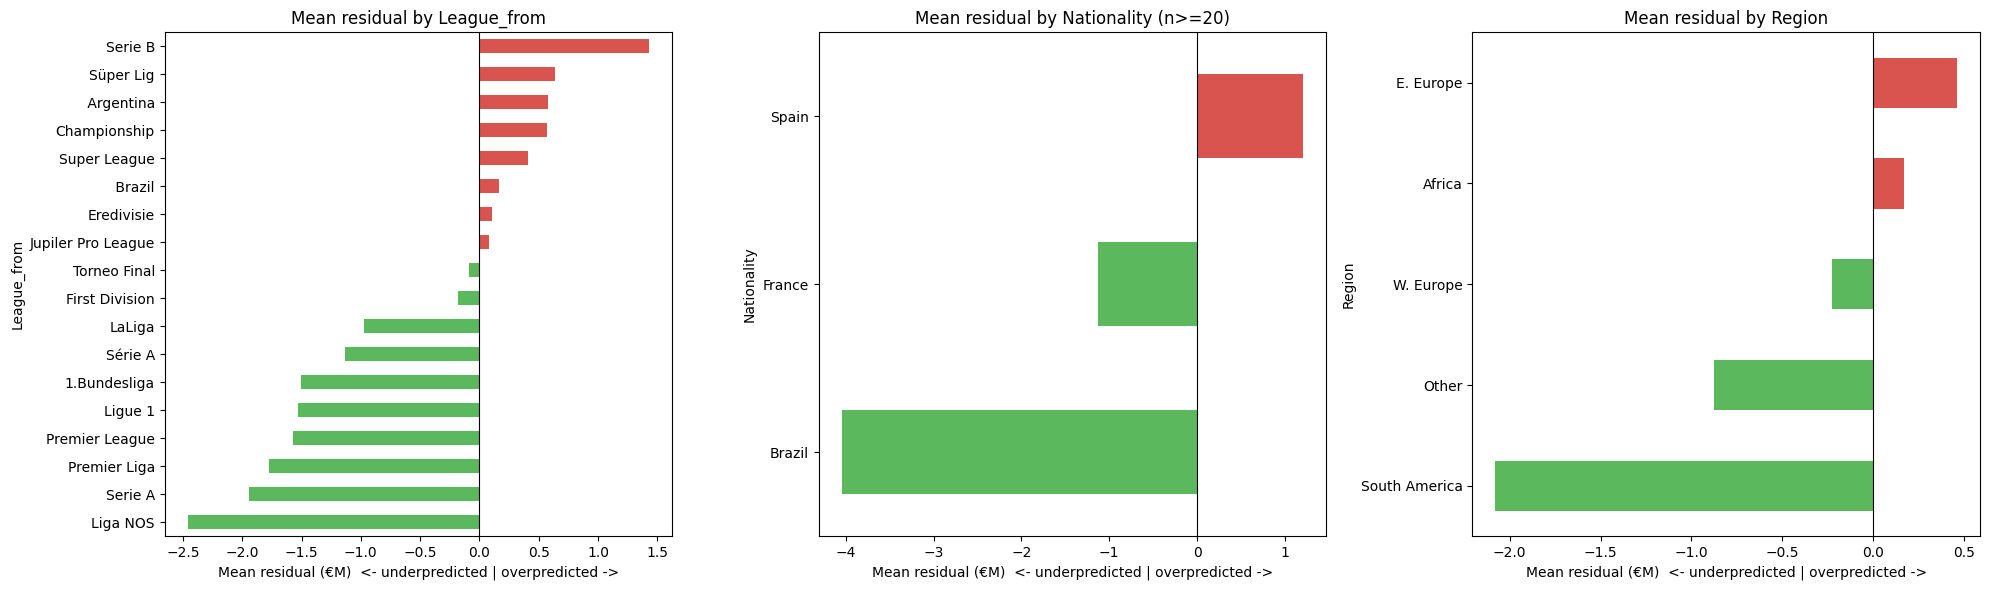


=== MAE / RMSE by League_from ===


,n,MAE,RMSE
League_from,,,
LaLiga,118,6.371,9.799
Liga NOS,50,6.337,8.758
1.Bundesliga,62,6.198,10.205
Premier League,194,5.854,9.663
Serie A,174,5.535,8.932
Série A,70,4.804,9.997
Premier Liga,53,4.669,8.045
Ligue 1,129,4.211,9.628
Championship,51,3.632,6.238



=== MAE / RMSE by Nationality (n >= 20) ===


,n,MAE,RMSE
Nationality,,,
France,27,9.727,19.573
Brazil,28,8.858,14.055
Spain,20,8.246,11.700



=== MAE / RMSE by Region ===


,n,MAE,RMSE
Region,,,
W. Europe,130,8.152,14.190
South America,59,7.830,12.099
Africa,30,5.654,7.388
E. Europe,25,4.618,5.653
Other,1159,3.705,6.441


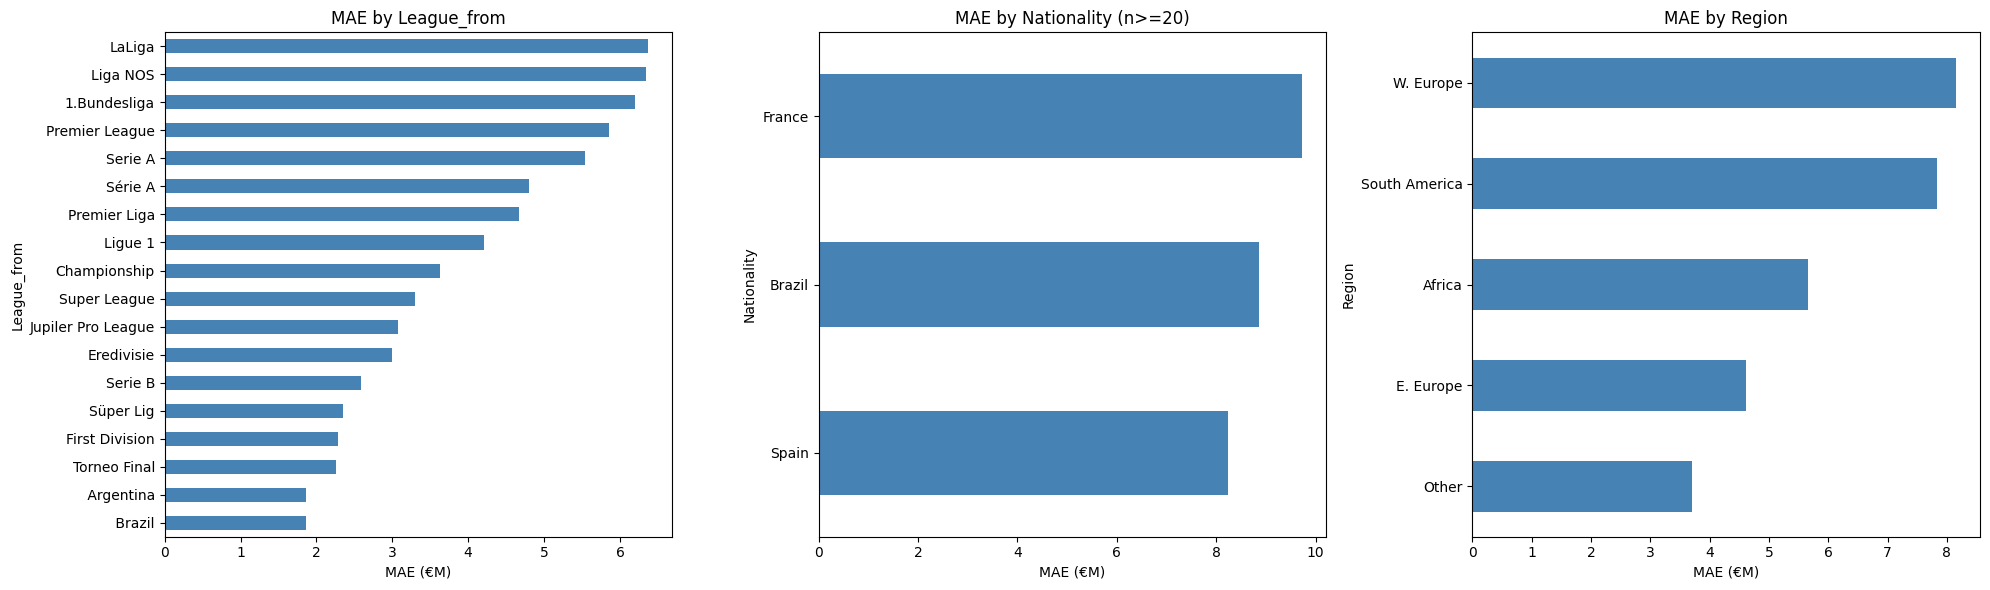


=== Mean residual by predicted-fee quintile x Region ===


mean_residual    n
pred_bin         Region                              
(1.292, 4.242]   Other                    -0.514  282
(4.242, 6.001]   Other                    -0.799  282
(6.001, 7.961]   Africa                    0.345    1
                 Asia & Oceania           -0.103    1
                 Other                    -0.688  265
                 South America             0.216    6
                 W. Europe                 0.874    8
(7.961, 11.995]  Africa                   -1.091   14
                 Americas (other)          2.773    2
                 E. Europe                -1.226   13
                 Other                    -1.441  173
                 South America            -4.131   30
                 W. Europe                -2.671   50
(11.995, 49.825] Africa                    1.337   15
                 Americas (other)          9.526    1
                 Asia & Oceania            6.812    2
                 E. Europe                 2.288   12
                 Other                    -1.364  157
                 South America             0.002   23
                 W. Europe                 1.350   72

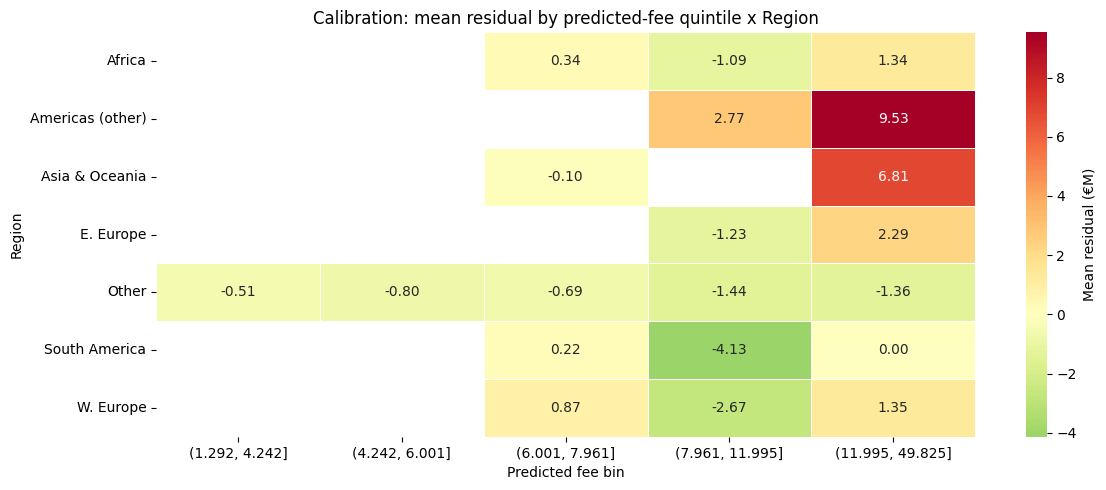

In [16]:
# Fairness metrics for the baseline RF model
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

MIN_N = 20

# Ensure baseline artifacts exist even if this fairness cell is run before the baseline-model section.
if not all(v in globals() for v in ['X_test_base', 'y_test_base', 'y_pred_rfr']):
    transfers_baseline = transfers_cleaned.drop(columns=['Name', 'Market_value_in_mln']).copy()
    transfers_baseline = pd.get_dummies(transfers_baseline)

    y_baseline = transfers_baseline['Transfer_fee_in_mln']
    X_baseline = transfers_baseline.drop(columns=['Transfer_fee_in_mln'])

    X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
        X_baseline, y_baseline, random_state=69, test_size=0.3
    )

    rfr_baseline = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
    rfr_baseline.fit(X_train_base, y_train_base)
    y_pred_rfr = rfr_baseline.predict(X_test_base)

eval_df = transfers_cleaned.loc[X_test_base.index].copy()
eval_df['y_true'] = y_test_base.values
eval_df['y_pred'] = y_pred_rfr
eval_df['residual'] = eval_df['y_pred'] - eval_df['y_true']
eval_df['abs_error'] = eval_df['residual'].abs()

if 'Lastname' not in eval_df.columns:
    eval_df['Lastname'] = eval_df['Name'].str.split(' ').str[-1]

eval_df['Lastname'] = (
    eval_df['Lastname'].astype(str)
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

_nat_frames = []
with zipfile.ZipFile('../data/ratings.zip') as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr - 2000}.csv'))
        nat_col = next((c for c in ['nationality_name', 'nationality'] if c in f.columns), None)
        if nat_col is None:
            continue
        mini = f[['short_name', nat_col]].copy()
        mini.columns = ['short_name', 'Nationality']
        mini['Lastname'] = (
            mini['short_name'].str.split(' ').str[-1]
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('utf-8')
        )
        mini['_season'] = yr
        _nat_frames.append(mini[['Lastname', '_season', 'Nationality']].drop_duplicates())

_nat_lookup = pd.concat(_nat_frames, ignore_index=True).drop_duplicates(subset=['Lastname', '_season'], keep='first')
eval_df['_season'] = eval_df['Season_transferred'].astype(int)
eval_df = eval_df.merge(_nat_lookup, how='left', on=['Lastname', '_season']).drop(columns=['_season'])

REGION_MAP = {
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Uruguay': 'South America', 'Chile': 'South America', 'Paraguay': 'South America',
    'Ecuador': 'South America', 'Peru': 'South America', 'Venezuela': 'South America',
    'France': 'W. Europe', 'Spain': 'W. Europe', 'Germany': 'W. Europe',
    'Italy': 'W. Europe', 'Portugal': 'W. Europe', 'Netherlands': 'W. Europe',
    'Belgium': 'W. Europe', 'England': 'W. Europe', 'Switzerland': 'W. Europe',
    'Austria': 'W. Europe', 'Scotland': 'W. Europe', 'Wales': 'W. Europe',
    'Republic of Ireland': 'W. Europe', 'Denmark': 'W. Europe', 'Sweden': 'W. Europe',
    'Norway': 'W. Europe', 'Finland': 'W. Europe',
    'Poland': 'E. Europe', 'Czech Republic': 'E. Europe', 'Croatia': 'E. Europe',
    'Serbia': 'E. Europe', 'Bosnia Herzegovina': 'E. Europe', 'Romania': 'E. Europe',
    'Hungary': 'E. Europe', 'Slovakia': 'E. Europe', 'Slovenia': 'E. Europe',
    'Bulgaria': 'E. Europe', 'Ukraine': 'E. Europe', 'Russia': 'E. Europe',
    'Greece': 'E. Europe', 'Turkey': 'E. Europe', 'Albania': 'E. Europe',
    'Montenegro': 'E. Europe', 'Georgia': 'E. Europe',
    'Senegal': 'Africa', 'Ivory Coast': 'Africa', "Côte d'Ivoire": 'Africa',
    'Ghana': 'Africa', 'Nigeria': 'Africa', 'Cameroon': 'Africa',
    'DR Congo': 'Africa', 'Mali': 'Africa', 'Guinea': 'Africa', 'Gabon': 'Africa',
    'Morocco': 'Africa', 'Algeria': 'Africa', 'Tunisia': 'Africa', 'Egypt': 'Africa',
    'Congo': 'Africa',
    'Mexico': 'Americas (other)', 'United States': 'Americas (other)',
    'Canada': 'Americas (other)', 'Jamaica': 'Americas (other)',
    'Costa Rica': 'Americas (other)', 'Honduras': 'Americas (other)',
    'Japan': 'Asia & Oceania', 'South Korea': 'Asia & Oceania',
    'Australia': 'Asia & Oceania', 'Iran': 'Asia & Oceania',
}
eval_df['Region'] = eval_df['Nationality'].map(REGION_MAP).fillna('Other')

print(f"Evaluation set size: {len(eval_df)}")
print(f"Nationality coverage: {eval_df['Nationality'].notna().sum()} / {len(eval_df)}")

def residual_summary(df, group_col, min_n=MIN_N):
    stats = (
        df.groupby(group_col)['residual']
        .agg(['count', 'mean', 'median'])
        .rename(columns={'count': 'n', 'mean': 'mean_residual', 'median': 'median_residual'})
    )
    return stats[stats['n'] >= min_n].sort_values('mean_residual').round(3)

league_res = residual_summary(eval_df, 'League_from')
nat_res = residual_summary(eval_df.dropna(subset=['Nationality']), 'Nationality')
region_res = residual_summary(eval_df, 'Region', min_n=5)

print('\n=== Signed residual by League_from ===')
display(league_res)
print(f"\n=== Signed residual by Nationality (n >= {MIN_N}) ===")
display(nat_res)
print('\n=== Signed residual by Region ===')
display(region_res)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, data, title in [
    (axes[0], league_res, 'Mean residual by League_from'),
    (axes[1], nat_res, f'Mean residual by Nationality (n>={MIN_N})'),
    (axes[2], region_res, 'Mean residual by Region'),
]:
    colors = ['#d9534f' if v > 0 else '#5cb85c' for v in data['mean_residual']]
    data['mean_residual'].plot.barh(ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Mean residual (€M)  <- underpredicted | overpredicted ->')
    ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

def error_summary(df, group_col, min_n=MIN_N):
    stats = df.groupby(group_col).agg(
        n=('residual', 'count'),
        MAE=('abs_error', 'mean'),
        RMSE=('residual', lambda x: np.sqrt((x ** 2).mean())),
    )
    return stats[stats['n'] >= min_n].sort_values('MAE', ascending=False).round(3)

league_err = error_summary(eval_df, 'League_from')
nat_err = error_summary(eval_df.dropna(subset=['Nationality']), 'Nationality')
region_err = error_summary(eval_df, 'Region', min_n=5)

print('\n=== MAE / RMSE by League_from ===')
display(league_err)
print(f"\n=== MAE / RMSE by Nationality (n >= {MIN_N}) ===")
display(nat_err)
print('\n=== MAE / RMSE by Region ===')
display(region_err)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, data, title in [
    (axes[0], league_err, 'MAE by League_from'),
    (axes[1], nat_err, f'MAE by Nationality (n>={MIN_N})'),
    (axes[2], region_err, 'MAE by Region'),
]:
    data['MAE'].sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('MAE (€M)')
plt.tight_layout()
plt.show()

eval_df['pred_bin'] = pd.qcut(eval_df['y_pred'], q=5, duplicates='drop')
cal_table = (
    eval_df.groupby(['pred_bin', 'Region'])['residual']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'mean_residual', 'count': 'n'})
    .round(3)
)
print('\n=== Mean residual by predicted-fee quintile x Region ===')
display(cal_table)

cal_pivot = eval_df.groupby(['pred_bin', 'Region'])['residual'].mean().unstack(fill_value=np.nan)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cal_pivot.T, annot=True, fmt='.2f', center=0, cmap='RdYlGn_r', linewidths=0.5,
    cbar_kws={'label': 'Mean residual (€M)'}, ax=ax,
)
ax.set_title('Calibration: mean residual by predicted-fee quintile x Region')
ax.set_xlabel('Predicted fee bin')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

=== Signed residual by League_from ===


,n,mean_residual,median_residual
League_from,,,
Liga NOS,50,-2.460,-0.138
Serie A,174,-1.941,-0.228
Premier Liga,53,-1.774,0.313
Premier League,194,-1.576,0.283
Ligue 1,129,-1.528,0.149
1.Bundesliga,62,-1.502,-0.266
Série A,70,-1.132,0.061
LaLiga,118,-0.976,0.632
First Division,20,-0.181,0.018



=== Signed residual by Nationality (n >= 20) ===


,n,mean_residual,median_residual
Nationality,,,
Brazil,28,-4.047,1.368
France,27,-1.131,2.574
Spain,20,1.207,2.449



=== Signed residual by Region ===


...

,n,MAE,RMSE
Nationality,,,
France,27,9.727,19.573
Brazil,28,8.858,14.055
Spain,20,8.246,11.700



=== MAE / RMSE by Region ===


,n,MAE,RMSE
Region,,,
W. Europe,130,8.152,14.190
South America,59,7.830,12.099
Africa,30,5.654,7.388
E. Europe,25,4.618,5.653
Other,1159,3.705,6.441



=== Mean residual by predicted-fee quintile x Region ===


mean_residual    n
pred_bin         Region                              
(1.292, 4.242]   Other                    -0.514  282
(4.242, 6.001]   Other                    -0.799  282
(6.001, 7.961]   Africa                    0.345    1
                 Asia & Oceania           -0.103    1
                 Other                    -0.688  265
                 South America             0.216    6
                 W. Europe                 0.874    8
(7.961, 11.995]  Africa                   -1.091   14
                 Americas (other)          2.773    2
                 E. Europe                -1.226   13
                 Other                    -1.441  173
                 South America            -4.131   30
                 W. Europe                -2.671   50
(11.995, 49.825] Africa                    1.337   15
                 Americas (other)          9.526    1
                 Asia & Oceania            6.812    2
                 E. Europe                 2.288   12
                 Other                    -1.364  157
                 South America             0.002   23
                 W. Europe                 1.350   72

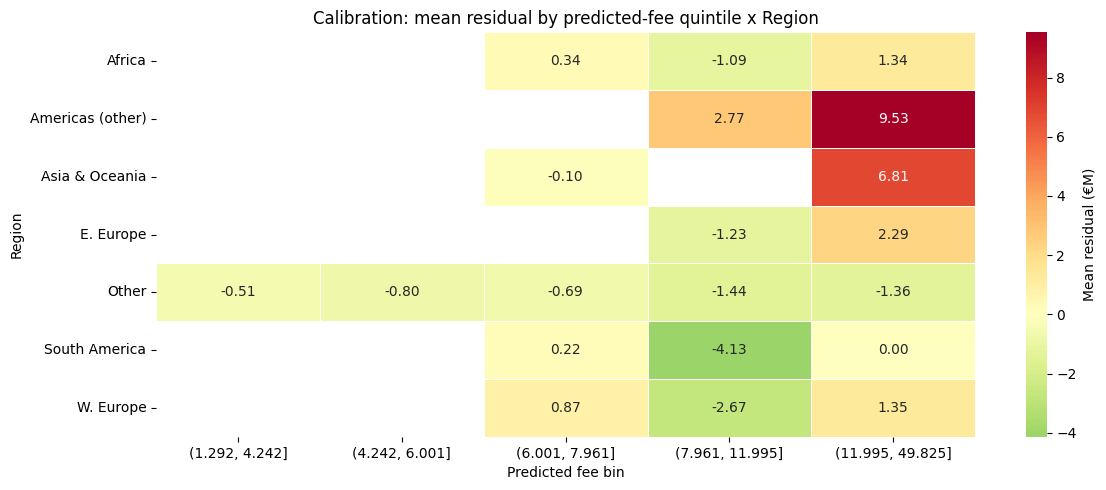

In [17]:
# Fairness metrics (robust baseline-aligned version)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

MIN_N = 20

if 'rfr_baseline' not in globals():
    raise ValueError('Run the baseline random forest cell first to create rfr_baseline.')

y_pred_eval = rfr_baseline.predict(X_test_base)

eval_df = transfers_cleaned.loc[X_test_base.index].copy()
eval_df['y_true'] = y_test_base.values
eval_df['y_pred'] = y_pred_eval
eval_df['residual'] = eval_df['y_pred'] - eval_df['y_true']
eval_df['abs_error'] = eval_df['residual'].abs()

if 'Lastname' not in eval_df.columns:
    eval_df['Lastname'] = eval_df['Name'].str.split(' ').str[-1]

eval_df['Lastname'] = (
    eval_df['Lastname'].astype(str)
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

nat_frames = []
with zipfile.ZipFile('../data/ratings.zip') as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr - 2000}.csv'))
        nat_col = next((c for c in ['nationality_name', 'nationality'] if c in f.columns), None)
        if nat_col is None:
            continue
        mini = f[['short_name', nat_col]].copy()
        mini.columns = ['short_name', 'Nationality']
        mini['Lastname'] = (
            mini['short_name'].str.split(' ').str[-1]
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('utf-8')
        )
        mini['_season'] = yr
        nat_frames.append(mini[['Lastname', '_season', 'Nationality']].drop_duplicates())

nat_lookup = pd.concat(nat_frames, ignore_index=True).drop_duplicates(subset=['Lastname', '_season'], keep='first')
eval_df['_season'] = eval_df['Season_transferred'].astype(int)
eval_df = eval_df.merge(nat_lookup, how='left', on=['Lastname', '_season']).drop(columns=['_season'])

REGION_MAP = {
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Uruguay': 'South America', 'Chile': 'South America', 'Paraguay': 'South America',
    'Ecuador': 'South America', 'Peru': 'South America', 'Venezuela': 'South America',
    'France': 'W. Europe', 'Spain': 'W. Europe', 'Germany': 'W. Europe',
    'Italy': 'W. Europe', 'Portugal': 'W. Europe', 'Netherlands': 'W. Europe',
    'Belgium': 'W. Europe', 'England': 'W. Europe', 'Switzerland': 'W. Europe',
    'Austria': 'W. Europe', 'Scotland': 'W. Europe', 'Wales': 'W. Europe',
    'Republic of Ireland': 'W. Europe', 'Denmark': 'W. Europe', 'Sweden': 'W. Europe',
    'Norway': 'W. Europe', 'Finland': 'W. Europe',
    'Poland': 'E. Europe', 'Czech Republic': 'E. Europe', 'Croatia': 'E. Europe',
    'Serbia': 'E. Europe', 'Bosnia Herzegovina': 'E. Europe', 'Romania': 'E. Europe',
    'Hungary': 'E. Europe', 'Slovakia': 'E. Europe', 'Slovenia': 'E. Europe',
    'Bulgaria': 'E. Europe', 'Ukraine': 'E. Europe', 'Russia': 'E. Europe',
    'Greece': 'E. Europe', 'Turkey': 'E. Europe', 'Albania': 'E. Europe',
    'Montenegro': 'E. Europe', 'Georgia': 'E. Europe',
    'Senegal': 'Africa', 'Ivory Coast': 'Africa', "Côte d'Ivoire": 'Africa',
    'Ghana': 'Africa', 'Nigeria': 'Africa', 'Cameroon': 'Africa',
    'DR Congo': 'Africa', 'Mali': 'Africa', 'Guinea': 'Africa', 'Gabon': 'Africa',
    'Morocco': 'Africa', 'Algeria': 'Africa', 'Tunisia': 'Africa', 'Egypt': 'Africa',
    'Congo': 'Africa',
    'Mexico': 'Americas (other)', 'United States': 'Americas (other)',
    'Canada': 'Americas (other)', 'Jamaica': 'Americas (other)',
    'Costa Rica': 'Americas (other)', 'Honduras': 'Americas (other)',
    'Japan': 'Asia & Oceania', 'South Korea': 'Asia & Oceania',
    'Australia': 'Asia & Oceania', 'Iran': 'Asia & Oceania',
}
eval_df['Region'] = eval_df['Nationality'].map(REGION_MAP).fillna('Other')

def residual_summary(df, group_col, min_n=MIN_N):
    s = (
        df.groupby(group_col)['residual']
        .agg(['count', 'mean', 'median'])
        .rename(columns={'count': 'n', 'mean': 'mean_residual', 'median': 'median_residual'})
    )
    return s[s['n'] >= min_n].sort_values('mean_residual').round(3)

def error_summary(df, group_col, min_n=MIN_N):
    s = df.groupby(group_col).agg(
        n=('residual', 'count'),
        MAE=('abs_error', 'mean'),
        RMSE=('residual', lambda x: np.sqrt((x ** 2).mean())),
    )
    return s[s['n'] >= min_n].sort_values('MAE', ascending=False).round(3)

league_res = residual_summary(eval_df, 'League_from')
nat_res = residual_summary(eval_df.dropna(subset=['Nationality']), 'Nationality')
region_res = residual_summary(eval_df, 'Region', min_n=5)

league_err = error_summary(eval_df, 'League_from')
nat_err = error_summary(eval_df.dropna(subset=['Nationality']), 'Nationality')
region_err = error_summary(eval_df, 'Region', min_n=5)

print('=== Signed residual by League_from ===')
display(league_res)
print(f'\n=== Signed residual by Nationality (n >= {MIN_N}) ===')
display(nat_res)
print('\n=== Signed residual by Region ===')
display(region_res)

print('\n=== MAE / RMSE by League_from ===')
display(league_err)
print(f'\n=== MAE / RMSE by Nationality (n >= {MIN_N}) ===')
display(nat_err)
print('\n=== MAE / RMSE by Region ===')
display(region_err)

eval_df['pred_bin'] = pd.qcut(eval_df['y_pred'], q=5, duplicates='drop')
cal_table = (
    eval_df.groupby(['pred_bin', 'Region'])['residual']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'mean_residual', 'count': 'n'})
    .round(3)
)
print('\n=== Mean residual by predicted-fee quintile x Region ===')
display(cal_table)

cal_pivot = eval_df.groupby(['pred_bin', 'Region'])['residual'].mean().unstack(fill_value=np.nan)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cal_pivot.T, annot=True, fmt='.2f', center=0, cmap='RdYlGn_r', linewidths=0.5,
    cbar_kws={'label': 'Mean residual (€M)'}, ax=ax,
)
ax.set_title('Calibration: mean residual by predicted-fee quintile x Region')
ax.set_xlabel('Predicted fee bin')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

## 7. Model Training: Linear Regression Baseline

In [18]:
# Drop name-specific identifiers
df_ml = final_df.drop(columns=['Name', 'Lastname', 'Team_from', 'Team_to', 'Nationality', 'overall_from', 'potential_from', 'overall_to', 'potential_to', 'Nat_to'])
df_ml = pd.get_dummies(df_ml)

X = df_ml.drop(columns=['Transfer_fee_in_mln'])
y = df_ml['Transfer_fee_in_mln']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

MSE: 117.06
R2: 0.65


In [19]:
# Baseline RF model (no engineered FIFA features, mirroring adjusted original approach)
transfers_baseline = transfers_cleaned.drop(columns=['Name', 'Market_value_in_mln']).copy()
transfers_baseline = pd.get_dummies(transfers_baseline)

y_baseline = transfers_baseline['Transfer_fee_in_mln']
X_baseline = transfers_baseline.drop(columns=['Transfer_fee_in_mln'])

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, random_state=69, test_size=0.3
)
print(X_train_base.shape)
print(X_test_base.shape)
print(y_train_base.shape)
print(y_test_base.shape)

rfr_baseline = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr_baseline.fit(X_train_base, y_train_base)
y_pred_rfr = rfr_baseline.predict(X_test_base)

print(f"MSE: {mean_squared_error(y_test_base, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test_base, y_pred_rfr):.2f}")

(3287, 1090)
(1409, 1090)
(3287,)
(1409,)
MSE: 60.72
R2: 0.36


## 8. Improved Modeling: Random Forest Regressor

Using an ensemble method to capture non-linear relationships between ability, market value, and purchasing power.

In [20]:
rfr = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_rfr):.2f}")

MSE: 89.88
R2: 0.73


# SHAP/LIME 

# ICE/PDP Plots

## 9. Model Training with Pre-Processing Fairness Design

This section prepares an engineered-feature training set with fairness-aware pre-processing:
- keeps sensitive/context columns for auditing (not for model input),
- builds a stratified split by group and fee band,
- creates sample weights to reduce representation imbalance before training.

In [22]:
# --- Pre-processing fairness setup ---
import numpy as np
import pandas as pd

if 'final_df' in globals():
    base_df = final_df.copy()
else:
    base_df = transfers_cleaned.copy()

required_cols = ['Transfer_fee_in_mln']
missing_required = [c for c in required_cols if c not in base_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in modeling dataframe: {missing_required}")

# Keep context columns for fairness auditing, but do not use them directly as predictors.
drop_for_model = [
    c for c in [
        'Name', 'Lastname', 'Team_from', 'Team_to',
        'Nationality', 'Nat_to',
        'overall_from', 'potential_from', 'overall_to', 'potential_to'
    ] if c in base_df.columns
]

df_model = base_df.drop(columns=drop_for_model).copy()

if 'REGION_MAP' in globals() and 'Nationality' in base_df.columns:
    region_series = base_df['Nationality'].map(REGION_MAP).fillna('Other')
else:
    region_series = pd.Series(['Unknown'] * len(base_df), index=base_df.index)

context_df = pd.DataFrame(index=base_df.index)
context_df['Region'] = region_series
if 'League_from' in base_df.columns:
    context_df['League_from'] = base_df['League_from'].astype(str)
else:
    context_df['League_from'] = 'Unknown'

y_all = df_model['Transfer_fee_in_mln'].astype(float)
X_all = df_model.drop(columns=['Transfer_fee_in_mln'])
X_all = pd.get_dummies(X_all, drop_first=False)

# Build fairness-aware stratification key: group x target band.
fee_band = pd.qcut(y_all, q=5, duplicates='drop').astype(str)
strata_key = context_df['Region'].astype(str) + ' | ' + fee_band

# Robust stratification fallback chain.
# 1) Region x fee band
# 2) Region only
# 3) Unstratified split
stratify_vector = strata_key.copy()
strata_counts = stratify_vector.value_counts()
stratify_vector = stratify_vector.where(stratify_vector.map(strata_counts) >= 2)

if stratify_vector.isna().any() or stratify_vector.nunique() < 2:
    region_only = context_df['Region'].astype(str)
    region_counts = region_only.value_counts()
    if region_only.nunique() >= 2 and region_counts.min() >= 2:
        stratify_vector = region_only
        print('Using fallback stratification: Region only')
    else:
        stratify_vector = None
        print('Using fallback split: unstratified')
else:
    print('Using stratification: Region x fee band')

X_train_fair, X_test_fair, y_train_fair, y_test_fair = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=69,
    stratify=stratify_vector
)

context_train = context_df.loc[X_train_fair.index].copy()
context_test = context_df.loc[X_test_fair.index].copy()

# Inverse-frequency weights by Region in train split.
region_freq = context_train['Region'].value_counts(normalize=True)
region_weight = context_train['Region'].map(lambda g: 1.0 / region_freq[g])

# Also weight fee bands so high-value bands are not overwhelmed.
train_fee_band = pd.qcut(y_train_fair, q=5, duplicates='drop').astype(str)
fee_freq = train_fee_band.value_counts(normalize=True)
fee_weight = train_fee_band.map(lambda b: 1.0 / fee_freq[b])

sample_weight_fair = (region_weight.values * fee_weight.values)
sample_weight_fair = sample_weight_fair / np.mean(sample_weight_fair)

print('Pre-processing split complete')
print('Train shape:', X_train_fair.shape, '| Test shape:', X_test_fair.shape)
print('Regions in train:', context_train['Region'].nunique())
print('Sample-weight range:', round(sample_weight_fair.min(), 3), 'to', round(sample_weight_fair.max(), 3))

Using fallback stratification: Region only
Pre-processing split complete
Train shape: (267, 445) | Test shape: (115, 445)
Regions in train: 7
Sample-weight range: 0.22 to 23.126


## 10. Model Training Experiments with In-Processing Fairness

This section trains multiple Random Forest variants and evaluates each on:
- overall performance (RMSE, R2),
- fairness disparity (signed residual gap and MAE gap across Region).

In [23]:
# --- In-processing model experiments ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def fairness_eval_regression(y_true, y_pred, groups):
    eval_df_local = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': groups
    }).copy()
    eval_df_local['residual'] = eval_df_local['y_pred'] - eval_df_local['y_true']
    eval_df_local['abs_error'] = eval_df_local['residual'].abs()

    g = eval_df_local.groupby('group').agg(
        n=('residual', 'count'),
        mean_residual=('residual', 'mean'),
        MAE=('abs_error', 'mean')
    )

    g = g[g['n'] >= 10].copy()
    if g.empty:
        signed_gap = np.nan
        mae_gap = np.nan
    else:
        signed_gap = (g['mean_residual'].max() - g['mean_residual'].min())
        mae_gap = (g['MAE'].max() - g['MAE'].min())

    return g.sort_values('MAE', ascending=False), signed_gap, mae_gap


model_specs = {
    'rf_standard': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=1, random_state=169),
    'rf_weighted': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=1, random_state=169),
    'rf_conservative': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=5, random_state=169),
}

trained_models = {}
results_rows = []
fairness_tables = {}

for model_name, params in model_specs.items():
    model = RandomForestRegressor(**params)

    if model_name == 'rf_weighted':
        model.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)
    else:
        model.fit(X_train_fair, y_train_fair)

    pred_test = model.predict(X_test_fair)

    rmse = np.sqrt(mean_squared_error(y_test_fair, pred_test))
    r2 = r2_score(y_test_fair, pred_test)

    fairness_table, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_fair.values,
        y_pred=pred_test,
        groups=context_test['Region'].values
    )

    trained_models[model_name] = model
    fairness_tables[model_name] = fairness_table

    results_rows.append({
        'model': model_name,
        'RMSE': rmse,
        'R2': r2,
        'SignedResidualGap_Region': signed_gap,
        'MAEGap_Region': mae_gap
    })

results_df = pd.DataFrame(results_rows).sort_values(
    ['MAEGap_Region', 'SignedResidualGap_Region', 'RMSE'],
    ascending=[True, True, True]
)

print('Model comparison (lower gaps are fairer):')
display(results_df.round(4))

for model_name in fairness_tables:
    print(f'\nRegion-level errors for {model_name}:')
    display(fairness_tables[model_name].round(4))

Model comparison (lower gaps are fairer):


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region
0,rf_standard,11.3238,0.6105,5.8288,4.2651
1,rf_weighted,11.3837,0.6064,5.4661,4.3190
2,rf_conservative,15.9234,0.2298,6.8887,5.0145



Region-level errors for rf_standard:


,n,mean_residual,MAE
group,,,
South America,20,-2.6606,8.5037
W. Europe,60,-1.3374,6.1775
Other,14,3.1682,4.3851
Africa,11,-0.0432,4.2386



Region-level errors for rf_weighted:


,n,mean_residual,MAE
group,,,
South America,20,-2.3832,8.6949
W. Europe,60,-1.2807,6.1813
Africa,11,-0.4132,4.5551
Other,14,3.0829,4.3759



Region-level errors for rf_conservative:


,n,mean_residual,MAE
group,,,
South America,20,-1.5664,11.8784
W. Europe,60,-0.7446,9.1971
Africa,11,1.3251,6.8827
Other,14,5.3223,6.8639


## 11. Simpson's Paradox Check During Model Training

This section compares global group residuals against within-strata residuals (League and predicted-fee bins) to detect reversals that indicate potential Simpson's paradox.

In [24]:
# --- Simpson's paradox diagnostics ---
# Pick the fairest model from the in-processing table (first row after sorting).
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

simpson_df = context_test.copy()
simpson_df['y_true'] = y_test_fair.values
simpson_df['y_pred'] = best_model.predict(X_test_fair)
simpson_df['residual'] = simpson_df['y_pred'] - simpson_df['y_true']

# Global residual by Region.
global_region = simpson_df.groupby('Region')['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_global', 'mean': 'global_mean_residual'}
)

# Within-League residual by Region.
within_league = simpson_df.groupby(['League_from', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_league = within_league[within_league['n_within'] >= 8]

# Within predicted-fee-bin residual by Region.
simpson_df['pred_bin'] = pd.qcut(simpson_df['y_pred'], q=5, duplicates='drop').astype(str)
within_pred_bin = simpson_df.groupby(['pred_bin', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_pred_bin = within_pred_bin[within_pred_bin['n_within'] >= 8]


def paradox_flag(global_table, within_table, strata_col):
    rows = []
    for region, g_row in global_table.iterrows():
        g_mean = g_row['global_mean_residual']
        if pd.isna(g_mean) or g_row['n_global'] < 15:
            continue

        region_within = within_table[within_table['Region'] == region]
        if region_within.empty:
            continue

        same_sign_share = np.mean(np.sign(region_within['within_mean_residual']) == np.sign(g_mean))

        rows.append({
            'Region': region,
            'global_mean_residual': g_mean,
            f'strata_count_{strata_col}': region_within[strata_col].nunique(),
            f'same_sign_share_{strata_col}': same_sign_share,
            f'possible_paradox_{strata_col}': same_sign_share < 0.5
        })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values('global_mean_residual')

paradox_league = paradox_flag(global_region, within_league, 'League_from')
paradox_predbin = paradox_flag(global_region, within_pred_bin, 'pred_bin')

print(f"Simpson diagnostics based on model: {best_model_name}")
print('\nGlobal residual by Region:')
display(global_region.round(4))

print('\nPotential sign-reversal flags (within League_from strata):')
display(paradox_league.round(4))

print('\nPotential sign-reversal flags (within predicted-fee-bin strata):')
display(paradox_predbin.round(4))

Simpson diagnostics based on model: rf_standard

Global residual by Region:


,n_global,global_mean_residual
Region,,
Africa,11,-0.0432
Americas (other),2,-0.8708
Asia & Oceania,1,3.4892
E. Europe,7,0.9240
Other,14,3.1682
South America,20,-2.6606
W. Europe,60,-1.3374



Potential sign-reversal flags (within League_from strata):


,Region,global_mean_residual,strata_count_League_from,same_sign_share_League_from,possible_paradox_League_from
0,W. Europe,-1.3374,2,0.5,False



Potential sign-reversal flags (within predicted-fee-bin strata):


,Region,global_mean_residual,strata_count_pred_bin,same_sign_share_pred_bin,possible_paradox_pred_bin
0,W. Europe,-1.3374,5,0.2,True


## 12. Hierarchical Strategy: Global Model + Group Residual Models

This section trains a hierarchical approach:
- a global random forest for base signal,
- per-region residual models for groups with enough training data,
- fallback to global-only predictions for sparse groups.

In [25]:
# --- Hierarchical model training ---
min_group_n = 80

# Global model uses fairness-aware sample weights from Section 9.
global_model = RandomForestRegressor(
    n_estimators=350,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=169
)
global_model.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)

# Train-group residual targets.
global_pred_train = global_model.predict(X_train_fair)
residual_train = y_train_fair.values - global_pred_train

train_h = X_train_fair.copy()
train_h['Region'] = context_train['Region'].values
train_h['residual_target'] = residual_train

# Fit one residual model per sufficiently large Region.
region_models = {}
region_counts = train_h['Region'].value_counts()
eligible_regions = region_counts[region_counts >= min_group_n].index.tolist()

for region in eligible_regions:
    subset = train_h[train_h['Region'] == region]
    X_r = subset.drop(columns=['Region', 'residual_target'])
    y_r = subset['residual_target'].values

    # Small residual model to avoid overfitting sparse local structure.
    region_model = RandomForestRegressor(
        n_estimators=120,
        max_features='sqrt',
        min_samples_leaf=8,
        random_state=169
    )
    region_model.fit(X_r, y_r)
    region_models[region] = region_model

# Predict on test set: global + optional region residual correction.
global_pred_test = global_model.predict(X_test_fair)
hier_pred_test = global_pred_test.copy()

for i, idx in enumerate(X_test_fair.index):
    region = context_test.loc[idx, 'Region']
    if region in region_models:
        row_features = X_test_fair.loc[[idx]]
        correction = region_models[region].predict(row_features)[0]
        hier_pred_test[i] += correction

# Compare hierarchical against best in-processing single model.
best_single_name = results_df.iloc[0]['model']
best_single_model = trained_models[best_single_name]
best_single_pred = best_single_model.predict(X_test_fair)

comparison_rows = []
for label, preds in [
    (f'single_{best_single_name}', best_single_pred),
    ('hierarchical_global_plus_region', hier_pred_test)
]:
    rmse = np.sqrt(mean_squared_error(y_test_fair, preds))
    r2 = r2_score(y_test_fair, preds)
    fair_tbl, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_fair.values,
        y_pred=preds,
        groups=context_test['Region'].values
    )

    comparison_rows.append({
        'model': label,
        'RMSE': rmse,
        'R2': r2,
        'SignedResidualGap_Region': signed_gap,
        'MAEGap_Region': mae_gap,
        'RegionsWithResidualModel': len(region_models)
    })

hier_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['MAEGap_Region', 'SignedResidualGap_Region', 'RMSE'],
    ascending=[True, True, True]
)

print('Hierarchical strategy comparison:')
display(hier_comparison_df.round(4))

print('Regions with local residual models:')
print(sorted(region_models.keys()))

Hierarchical strategy comparison:


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region,RegionsWithResidualModel
0,single_rf_standard,11.3238,0.6105,5.8288,4.2651,1
1,hierarchical_global_plus_region,13.9204,0.4114,6.4072,4.7973,1


Regions with local residual models:
['W. Europe']
